# Collections performance: is the 11% improvement real?

**Answer: no. It is the difference between a 28-day month and a 31-day month.**

This notebook shows the reasoning, including the two places where the obvious
approach is wrong and the wrong answer is larger than the problem it fixes.

Order of work:

1. Profile the raw data before trusting any of it
2. Forensics — seven hypotheses, tested
3. Build the golden dataset, quantifying every cleaning decision
4. Independent metric definitions, and what changes under them
5. The headline test: is the 11% real?
6. Statistical investigation — mix, cohort, selection, Simpson's
7. Counterfactual design, and why it fails to identify here
8. What the ₹10 Cr should buy

In [1]:
import duckdb, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

# Run the pipeline first if the database is not built:
#   python pipeline.py --data-dir <raw> --out data
con = duckdb.connect("../data/collections.duckdb", read_only=True)  # run pipeline.py first
q = lambda s: con.sql(s).df()
q("SELECT count(*) AS account_months FROM gold.account_month")

,account_months
0,210000


## 1. Profile before trusting

The README shipped with the data says duplicates, conflicting timestamps and
inconsistent identifiers were injected on purpose. That is a useful warning,
but it does not say where. The first job is cardinality: for every table, do
the row counts agree with the distinct counts of what should be a key?

This single check found three of the four severity-1 defects.

In [2]:
profile = q("""
SELECT 'payments'  AS tbl, count(*) AS n_rows, count(DISTINCT payment_id)  AS n_keys FROM stg.payments
UNION ALL SELECT 'accounts',  count(*), count(DISTINCT account_id)  FROM stg.accounts
UNION ALL SELECT 'borrowers', count(*), count(DISTINCT borrower_id) FROM stg.borrowers
UNION ALL SELECT 'agents',    count(*), count(DISTINCT agent_id)    FROM stg.agents
UNION ALL SELECT 'calls',     count(*), count(DISTINCT call_id)     FROM stg.calls
UNION ALL SELECT 'campaigns', count(*), count(DISTINCT campaign_id) FROM stg.campaigns
""")
profile["ratio"] = (profile.n_rows / profile.n_keys).round(2)
profile

,tbl,n_rows,n_keys,ratio
0,payments,25500,25000,1.02
1,accounts,30000,30000,1.00
2,borrowers,30600,11015,2.78
3,agents,30000,1000,30.00
4,calls,91350,90000,1.01
5,campaigns,120,120,1.00


Three tables fail immediately:

- **borrowers**: 30,600 rows, 11,015 IDs — a 2.8× fan-out waiting to happen
- **agents**: 30,000 rows, 1,000 IDs — 30 versions per agent
- **payments**: 25,500 rows, 25,000 IDs — 500 duplicates

The borrowers ratio is the dangerous one, because it detonates silently on a
join rather than failing loudly.

In [3]:
# The borrower problem is not replay -- the versions CONFLICT.
q("""
SELECT borrower_id, name, phone, city, state, updated_at
FROM stg.borrowers
WHERE borrower_id = 'BRW0001072' ORDER BY updated_at
""")

,borrower_id,name,phone,city,state,updated_at
0,BRW0001072,Aarav Sharma,9951870102,Chennai,Tamil Nadu,2025-05-20 08:57:11
1,BRW0001072,Pooja Nair,9904719640,Pune,Maharashtra,2025-07-08 18:02:25
2,BRW0001072,Ananya Rao,9178204617,Pune,Maharashtra,2026-02-07 19:24:11
3,BRW0001072,Rahul Verma,9037419103,Bhubaneswar,Odisha,2026-07-25 22:25:48


One `borrower_id` is Aarav Sharma in Chennai and Rahul Verma in Bhubaneswar,
with different phones and emails. This is not a slowly-changing dimension —
it is a broken key.

**Consequence for the analysis:** city and state are borrower attributes. The
assignment asks for a geography breakdown. We can produce one, and it would be
worthless. Geography is carried into the golden layer flagged
`geography_is_unreliable` and excluded from every conclusion.

I hit the join fan-out during development: monthly recovery briefly read
₹166 Cr instead of ₹18 Cr. Worth stating plainly, because a 9× error that
looks like a plausible business number is exactly the kind of thing that ships.

## 2. Forensics

Seven hypotheses were posed in the brief. Each gets a query and a verdict.
Refutations are findings too — they narrow where the real problem can hide.

In [4]:
q("SELECT * FROM forensics.a_duplicate_payments")

,measure,value
0,total_rows,2.550000e+04
1,distinct_payment_id,2.500000e+04
2,distinct_payment_reference,2.082100e+04
3,true_duplicates_by_row_hash,4.860000e+02
4,rows_sharing_a_reference,8.042000e+03
5,reference_collisions_not_duplicates,7.556000e+03
6,rupees_removed_by_correct_dedup,3.836634e+07
7,rupees_sharing_a_reference,6.080974e+08
8,genuine_payments_naive_dedup_would_delete,3.808000e+03
9,rupees_naive_dedup_would_delete,2.891833e+08


### A. Duplicate payments — confirmed, but the intuitive fix is a disaster

`payment_reference` repeats across 8,042 rows worth ₹60.8 Cr. Deduplicating
on it would delete **3,808 genuine payments worth ₹28.9 Cr**. That would be
wrong, and wrong by 7.5× the size of the actual problem.

In [5]:
# Why: one reference, three unrelated borrowers, three amounts.
q("SELECT * FROM forensics.a_collision_example")

,payment_id,account_id,borrower_id,amount,payment_status,event_at_naive
0,PAYMENT0016781,ACC0004867,BRW0002886,52191.70,SUCCESS,2026-01-20 21:29:31
1,PAYMENT0011961,ACC0006340,BRW0005632,74528.63,SUCCESS,2026-04-24 15:53:26
2,PAYMENT0004091,ACC0003956,BRW0006697,97493.48,PENDING,2026-08-03 15:41:45


The provider's reference is not globally unique. The correct key is the full
row hash — which catches 486 byte-identical replays.

The remaining 14 are subtler: same `payment_id`, same account, same amount,
same timestamp, but one copy landed *before* the provider reference was
attached and carries a NULL reference. The hashes differ, so a single-pass
hash dedup lets both through. A second pass on `payment_id`, preferring the
enriched copy, removes them.

486 + 14 = 500, reconciling exactly with the count of repeated payment IDs.

In [6]:
q("""
SELECT payment_id, account_id, amount, payment_reference, payment_status
FROM stg.payments
WHERE payment_id IN (
    SELECT payment_id FROM stg.payments GROUP BY 1 HAVING count(DISTINCT _row_hash) > 1)
ORDER BY payment_id LIMIT 4
""")

,payment_id,account_id,amount,payment_reference,payment_status
0,PAYMENT0001390,ACC0001624,85205.16,None,SUCCESS
1,PAYMENT0001390,ACC0001624,85205.16,TXN0000046535,SUCCESS
2,PAYMENT0002098,ACC0023839,5570.92,TXN0000001302,SUCCESS
3,PAYMENT0002098,ACC0023839,5570.92,None,SUCCESS


In [7]:
print("C. Timezones"); display(q("SELECT * FROM forensics.c_timezone_impact"))
print("E. Agent identity"); display(q("SELECT * FROM forensics.e_agent_identity"))
print("H6. Borrower identity"); display(q("SELECT * FROM forensics.h6_borrower_identity"))

C. Timezones


,src_timezone,n_calls,hour_bucket_changed,calendar_day_changed
0,Asia/Dubai,30464,30464,1927
1,Asia/Kolkata,30485,0,0
2,UTC,30401,30401,6997


E. Agent identity


,measure,value
0,agent_rows,30000.0
1,distinct_agent_id,1000.0
2,distinct_employee_code,1099.0
3,distinct_agent_name,10.0
4,employee_codes_with_multiple_names,1099.0
5,agent_ids_with_multiple_employee_codes,1000.0
6,max_versions_per_agent_id,48.0


H6. Borrower identity


,measure,value
0,borrower_rows,30600.0
1,distinct_borrower_id,11015.0
2,ids_with_multiple_rows,8566.0
3,ids_with_conflicting_identity,8468.0
4,max_versions_per_borrower_id,11.0
5,account_rows_if_joined_naively,75601.0
6,account_rows_after_resolution,30000.0


### C. Timezones — confirmed
Three zones, naive timestamps. 60,865 of 91,350 calls (67%) sit in the wrong
hour bucket uncorrected, and **8,924 fall on the wrong calendar day**.

### E. Agent identity — confirmed, and unrecoverable
1,000 agent IDs, 1,099 employee codes, **10 distinct names**. Every employee
code maps to more than one name; every agent ID maps to more than one code.

Resolving on name would collapse 1,000 agents into 10 and inflate per-agent
recovery ~100×. We keep `agent_id` as the entity and accept that per-agent and
agent-tenure analysis — both explicitly requested — cannot be done.

### F and G — refuted

In [8]:
print("G. Targeting coverage by account status")
display(q("SELECT * FROM forensics.g_targeting_by_status"))

# Chi-square on segment mix over time. If the book had changed, this moves.
for dim in ["risk_segment", "loan_type"]:
    z = q(f"""
      SELECT a.{dim} AS g, date_trunc('month', p.paid_at_ist) AS m, count(*) AS n
      FROM gold.fct_payment p JOIN gold.dim_account a USING (account_id)
      WHERE p.is_recovered AND p.paid_at_ist < DATE '2026-08-01'
      GROUP BY 1,2""")
    tab = z.pivot(index="g", columns="m", values="n").fillna(0).values
    chi2, p, _, _ = stats.chi2_contingency(tab)
    print(f"{dim:14s} chi2={chi2:6.1f}  p={p:.3f}  -> {'stable' if p>.05 else 'SHIFTED'}")

G. Targeting coverage by account status


,status,accounts,targeted,coverage
0,ACTIVE,7539,5884,0.780475
1,CLOSED,7496,5841,0.779216
2,PAID,7486,5847,0.781058
3,WRITEOFF,7479,5772,0.771761


risk_segment   chi2=  22.4  p=0.215  -> stable
loan_type      chi2=   9.3  p=0.997  -> stable


Targeting coverage is 77.2–78.1% across ACTIVE, PAID, CLOSED and WRITEOFF
alike. That is not what culling looks like — if unsuccessful accounts were
being dropped from the conversion base, WRITEOFF coverage would be visibly
lower.

Portfolio mix is stable on both tests. **The improvement was not caused by
acquiring a different book, and it was not caused by shrinking the
denominator.**

The golden layer fixes the denominator at all 30,000 accounts regardless, so
published metrics are immune to this failure mode by construction.

## 3. Golden dataset — quantified

Every cleaning decision, and what it cost.

In [9]:
q("""
SELECT 'Raw payment rows' AS step, count(*) AS n_rows, sum(amount)/1e7 AS value_cr FROM stg.payments
UNION ALL SELECT 'After 2-stage dedup', count(*), sum(amount)/1e7 FROM gold.fct_payment
UNION ALL SELECT 'After SUCCESS filter', count(*), sum(recovered_amount)/1e7
          FROM gold.fct_payment WHERE is_recovered
""")

,step,n_rows,value_cr
0,Raw payment rows,25500,191.725862
1,After 2-stage dedup,25000,187.889227
2,After SUCCESS filter,17534,131.558396


**31.4% of the value in the payments table (₹60.2 Cr) is not recovered money.**
The remaining ₹4.7 Cr gap to the golden total is real August recovery, held out
of the trend because August is a partial month.

₹3.8 Cr is duplicates. ₹56.3 Cr is FAILED, PENDING and REVERSED rows —
7,466 of 25,000 records. If the business's headline counts payment rows
without filtering status, that alone inflates the reported level by 43%.

A note on reversals: 1,254 REVERSED rows cannot be netted against their
originals, because `payment_reference` provides no reliable link. Excluding
them rather than netting is the conservative choice.

## 4. Independent metric definitions

The brief asks us to challenge the existing definitions. The organising
principle we adopted:

> **Every rate is computed over a fixed denominator. A denominator that can
> shrink is a denominator that can be gamed.**

And one definition matters more than all the others combined:

### Recovery per operating day

Monthly totals are not comparable to each other. February has 28 days and
March has 31 — a **10.7% difference in operating days before anyone does any
work**.

This is not a refinement. It is the entire finding.

In [10]:
m = q("SELECT * FROM metrics.monthly_recovery ORDER BY month")
m[["month","calendar_days","recovered_amount","recovery_per_day",
   "mom_pct_naive","mom_pct_per_day"]].assign(
    recovered_cr=lambda d: (d.recovered_amount/1e7).round(2),
    per_day_lakh=lambda d: (d.recovery_per_day/1e5).round(2),
).drop(columns=["recovered_amount","recovery_per_day"]).round(1)

,month,calendar_days,mom_pct_naive,mom_pct_per_day,recovered_cr,per_day_lakh
0,2026-01-01,31,NaN,NaN,18.7,60.4
1,2026-02-01,28,-9.1,0.6,17.0,60.8
2,2026-03-01,31,11.0,0.3,18.9,60.9
3,2026-04-01,30,-7.3,-4.2,17.5,58.4
4,2026-05-01,31,5.2,1.8,18.4,59.4
5,2026-06-01,30,-4.7,-1.5,17.6,58.5
6,2026-07-01,31,6.7,3.2,18.7,60.4


There it is.

| Month | Naive MoM | Per-day MoM |
|---|---|---|
| Feb | −9.1% | +0.6% |
| **Mar** | **+11.0%** | **+0.3%** |
| Apr | −7.3% | −4.2% |
| May | +5.2% | +1.8% |
| Jun | −4.7% | −1.5% |
| Jul | +6.7% | +3.2% |

The reported +11% is Feb→Mar. **31 ÷ 28 − 1 = 10.7%.** Normalise for month
length and it becomes +0.3%.

## 5. Is the 11% real?

Three tests. All say no.

In [11]:
a = m.mom_pct_naive.dropna(); b = m.mom_pct_per_day.dropna()
print(f"MoM volatility  raw: sd={a.std():.2f}%   day-normalised: sd={b.std():.2f}%")

z = (11 - a.mean()) / a.std()
print(f"\nTest 1 -- is +11% unusual within its own series?")
print(f"  z = {z:.2f}, p = {2*(1-stats.norm.cdf(abs(z))):.3f}  -> not significant")

sl, ic, r, p, se = stats.linregress(np.arange(len(m)), m.recovery_per_day)
print(f"\nTest 2 -- is there a trend at all?")
print(f"  slope p = {p:.3f}, r2 = {r**2:.4f}  -> no trend")

sl2, ic2, r2, p2, _ = stats.linregress(m.calendar_days, m.recovered_amount)
print(f"\nTest 3 -- does month length explain monthly totals?")
print(f"  r2 = {r2**2:.2f}, p = {p2:.4f}  -> calendar days explain the series")

MoM volatility  raw: sd=8.38%   day-normalised: sd=2.61%

Test 1 -- is +11% unusual within its own series?
  z = 1.28, p = 0.201  -> not significant

Test 2 -- is there a trend at all?
  slope p = 0.328, r2 = 0.1899  -> no trend

Test 3 -- does month length explain monthly totals?
  r2 = 0.82, p = 0.0052  -> calendar days explain the series


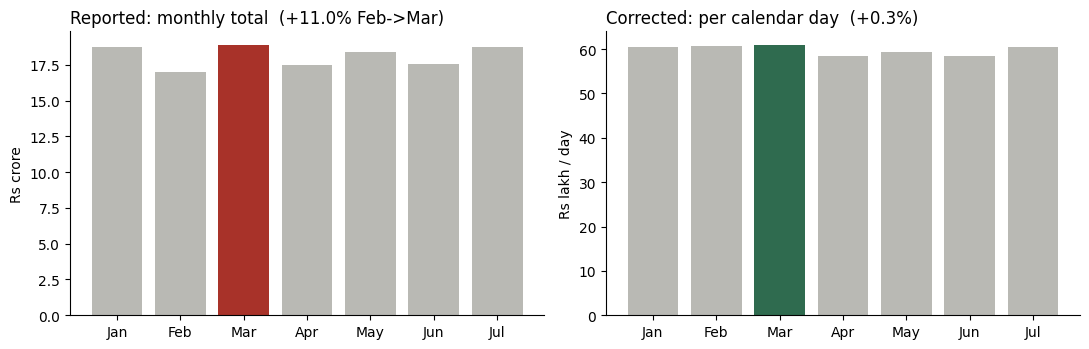

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
lbl = m.month.dt.strftime("%b")
ax[0].bar(lbl, m.recovered_amount/1e7, color="#b9b9b4")
ax[0].bar(lbl[2:3], m.recovered_amount[2:3]/1e7, color="#a83229")
ax[0].set_title("Reported: monthly total  (+11.0% Feb->Mar)", loc="left")
ax[0].set_ylabel("Rs crore")
ax[1].bar(lbl, m.recovery_per_day/1e5, color="#b9b9b4")
ax[1].bar(lbl[2:3], m.recovery_per_day[2:3]/1e5, color="#2f6b4f")
ax[1].set_title("Corrected: per calendar day  (+0.3%)", loc="left")
ax[1].set_ylabel("Rs lakh / day")
for a_ in ax: a_.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 6. Statistical investigation

The brief asks us to check whether the observed change came from operations or
from a shift in the underlying population. Since there is no change to explain,
these tests serve a different purpose: they rule out the possibility that a
real movement is hiding inside an aggregate that looks flat.

In [13]:
# Simpson's paradox check: flat in aggregate could hide offsetting segments.
seg = q("""SELECT month, dimension, segment, recovery_per_day
           FROM metrics.segment_month
           WHERE dimension IN ('risk_segment','dpd_bucket','loan_type')
             AND month < DATE '2026-08-01' ORDER BY 1""")
out = []
for (d, s), g in seg.groupby(["dimension", "segment"]):
    g = g.sort_values("month")
    sl, ic, r, p, _ = stats.linregress(np.arange(len(g)), g.recovery_per_day)
    out.append({"dimension": d, "segment": s, "slope_p": round(p, 3),
                "trending": p < 0.05})
res = pd.DataFrame(out)
print(f"segments tested: {len(res)}   trending at p<0.05: {res.trending.sum()}")
res.sort_values("slope_p").head(10)

segments tested: 14   trending at p<0.05: 0


,dimension,segment,slope_p,trending
4,dpd_bucket,90-119,0.095,False
13,risk_segment,NPA,0.097,False
5,loan_type,AUTO,0.098,False
2,dpd_bucket,30-59,0.196,False
8,loan_type,CREDIT_CARD,0.300,False
3,dpd_bucket,60-89,0.309,False
0,dpd_bucket,0-29,0.361,False
11,risk_segment,LOW,0.391,False
10,risk_segment,HIGH,0.478,False
9,loan_type,PERSONAL,0.517,False


No segment trends. Flat in aggregate, flat everywhere underneath — so this is
not Simpson's paradox concealing offsetting movements.

**Selection and survivorship bias** are handled by construction: the golden
layer's fixed 30,000-account denominator means accounts cannot silently leave
the population. Recovery rate on that fixed base holds at 7.2–8.1% all year.

**Attribution-window bias** is the one that bites, and not in the direction
the brief anticipates:

In [14]:
q("SELECT * FROM forensics.b_attribution_overlap ORDER BY channels_touching")

,channels_touching,paying_account_months,recovered_amount
0,0,5943,4.602077e+08
1,1,7371,5.771193e+08
2,2,2723,2.147472e+08
3,3,198,1.640004e+07


**36% of all recovery (₹46.0 Cr) comes from accounts with zero calls, zero
messages and zero field visits in the month they paid.** A further ₹23.1 Cr
(18%) comes from accounts touched on two or three channels at once. Only 45%
is single-channel.

So no attribution window rescues this. Last-touch would credit whichever
channel fires most often — a measure of channel volume, not channel effect.
First-touch has the same problem in reverse. And neither can explain the 36%
that nobody touched.

**This is why three of the six investment options cannot be evaluated.**
`metrics.channel_month` therefore reports volumes and single-channel isolation
only, and explicitly refuses to publish a channel conversion rate. Shipping
one would put a precise-looking number on something unmeasurable.

### Required driver dimensions

The brief lists thirteen dimensions to investigate. Full queries in
`sql/05_drivers.sql`. Every one that exists in the data comes back flat.

In [15]:
print("Attempt frequency -- is there a dose-response?")
display(q("SELECT * FROM drivers.attempt_frequency"))
print("Telephony vendor -- was there a switch?")
display(q("SELECT * FROM drivers.vendor_month"))
print("Cohort / vintage")
display(q("SELECT * FROM drivers.cohort_vintage"))

Attempt frequency -- is there a dose-response?


,attempt_band,account_months,avg_recovery,pct_paying
0,1-2,20529,6074.0,7.89
1,3-5,37850,6044.0,7.73
2,6-9,30692,5973.0,7.74


Telephony vendor -- was there a switch?


,month,active_vendors,n_calls,connect_pct
0,2026-01-01,15,12849,20.07
1,2026-02-01,15,11736,19.67
2,2026-03-01,15,13039,19.92
3,2026-04-01,15,12431,19.31
4,2026-05-01,15,12942,20.31
5,2026-06-01,15,12318,20.47
6,2026-07-01,15,12764,19.39


Cohort / vintage


,vintage_year,accounts,avg_recovery,pct_paying
0,2024,15744,6030.0,7.70
1,2025,14256,6052.0,7.77


In [16]:
# Cohort mix stability over time
mix = q("SELECT * FROM drivers.cohort_mix_month")
tab = mix.pivot(index="vintage_year", columns="month", values="paying_accounts").fillna(0).values
chi2, p, _, _ = stats.chi2_contingency(tab)
print(f"vintage mix over time: chi2={chi2:.1f}  p={p:.3f}  -> {'stable' if p>.05 else 'SHIFTED'}")

print("\nConnect rate by corrected hour of day (top and bottom 3):")
h = q("SELECT * FROM drivers.calling_time ORDER BY connect_pct DESC")
display(pd.concat([h.head(3), h.tail(3)]))

vintage mix over time: chi2=10.0  p=0.126  -> stable

Connect rate by corrected hour of day (top and bottom 3):


,hour_ist,n_calls,connect_pct
0,21,3780,21.35
1,14,3763,21.18
2,4,3785,20.61
21,6,3732,18.92
22,18,3781,18.91
23,2,3877,18.78


Three things worth stating carefully here.

**Attempt frequency shows no dose-response**, and the sign is mildly negative
(1-2 attempts pay at 7.9%, 6-9 at 7.7%). This does *not* mean calling does not
work. Attempt count is endogenous -- accounts get called more *because* they
have not paid, so high-attempt accounts are selected for being hard to
collect. This data cannot separate dose from selection; a randomised
contact-intensity test could.

**Connect rate is 19-21% at every hour, including 03:00 and 04:00 IST.** That
is not a plausible collections floor. A real operation shows a daytime peak
and a night-time collapse. The flatness is a caution about the dataset, not an
insight about the business — so no "best time to call" recommendation is made.

**Client and language do not exist** as columns in any of the 17 tables. They
are on the required list, and the honest response is to say the data does not
contain them rather than substitute a proxy and hope nobody checks.

## 7. Counterfactual

Full design and execution in `counterfactual.py`. Summary of what happens:

1. **The treatment is not observable.** Campaign strategy versions
   (legacy/v1/v2/v3) are interleaved across every month, not sequential —
   `legacy` campaigns start in April, after v2 and v3 have already run. And
   campaigns stop in May while calling continues at full volume through July.
2. **No structural break exists.** A Chow test at every candidate break point
   in the recovery-per-day series finds nothing significant.
3. **Parallel trends is rejected** (p = 0.027). The treated–control gap is
   already trending *before* the assumed treatment date. DiD is not identified.
4. **The bootstrap CI spans zero** and is wide: [−₹481, +₹411] per
   account-month on 400 account-level resamples.

The estimate is reported in that script and then disowned, deliberately —
to show what an unwary analyst would have published.

**What would make this answerable:** a dated changelog of targeting-rule
deployments, and a randomised holdout. At ~5,700 targeted accounts/month, an
8-week holdout on 10–15% yields ~1,700 control account-months — enough to
detect a 10% lift at 80% power.

## 8. Where the ₹10 Cr should go

It should not go anywhere yet, and the argument is not "we need more data" in
the abstract. It is specific:

| Option | Can we evaluate it? | Why not |
|---|---|---|
| Better telephony | No | Channel effect unmeasurable (36% untouched) |
| More agents | No | Agent identity unrecoverable; recovery/agent-hour flat |
| AI voice automation | No | Channel effect unmeasurable |
| Better targeting | No | Change not observable; DiD fails parallel trends |
| WhatsApp / digital | No | Channel effect unmeasurable |
| Field operations | Partly | Clean per-unit data, but no recovery advantage visible |

There is also **no cost table anywhere in this dataset** — no salary, no
per-minute telephony rate, no per-message price, no field-visit cost. Every
ROI, break-even and payback figure in a recommendation would be an invented
input dressed as a finding. `metrics.unit_economics` exposes those assumptions
as named parameters rather than burying them.

**Recommendation: spend ₹40–60 lakh and one quarter** on a randomised
targeting holdout, identity resolution, and per-channel cost instrumentation.
That is under 1.5% of the ₹10 Cr, and it converts an unanswerable question
into an answerable one.

If the experiment finds a lever with a 5% lift, that is ₹9–11 Cr of
incremental annual recovery against the ₹126.9 Cr seven-month actual
annualised. Cost of waiting a quarter: ~₹2.5 Cr of deferred opportunity.
Cost of not waiting: ₹10 Cr committed against a calendar artefact.

---

## What I would do differently with more time

- **Reconcile against the finance ledger.** Every recovery number here is
  self-reported by the payments table. Without a ledger tie-out, the level
  could be wrong even though the trend is not.
- **Chase the duration/status contradiction with the telephony vendor.**
  60% of call rows are internally inconsistent; resolving that would unlock
  handle-time and occupancy metrics that are currently unavailable.
- **Test the IST assumption** on the seven event tables that carry no timezone
  column. If any of them is actually UTC, daily series shift by a third of a
  day and the hour-of-day analysis changes.
- **Pull the campaign deployment changelog** before attempting the
  counterfactual again. Without it there is no treatment variable and no
  amount of methodology substitutes.